# ARTI 406 – Assignment 2

### Prepared by:
### Nora Alqahtani

### June 2026


- **Task 1**
Identify data quality issues in the dataset.



In [520]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1.1 Load Dataset

In [521]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Nike_Sales_Uncleaned.csv")
df.head(10)

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89
5,2005,Women,Training,Flex Trainer,M,1.0,7363.96,NaN,0.0,NaN,Retail,Delhi,1415.98
6,2006,Men,Training,SuperRep Go,M,NaN,6819.78,NaN,0.0,04-06-2025,Online,Bangalore,1802.09
7,2007,Kids,Training,SuperRep Go,M,1.0,NaN,0.32,0.0,NaN,Retail,Bangalore,2928.36
8,2008,Women,Soccer,Premier III,11,-1.0,NaN,NaN,0.0,11-10-2024,Online,Hyderabad,-731.18
9,2009,Men,Soccer,Mercurial Superfly,M,4.0,NaN,NaN,0.0,NaN,Online,Pune,3929.61


Most columns have appropriate data types. However, the Order_Date column is stored as an object instead of a datetime format, which may limit time-based analysis. Additionally, Units_Sold is stored as a float value although it may represent whole numbers.

## 1.2 Data Quality Assessment
### 1.2.1 Check Data Types


In [522]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


In [523]:
df.isna().sum() 

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

### 1.2.2 Convert Incorrect Data Types
We will convert:
- `Order_Date` to datetime format
- `Units_Sold` to integer


In [524]:
# Make a copy before cleaning
df_task1 = df.copy()
# Convert Units_Sold to integer
df_task1['Units_Sold'] = df_task1['Units_Sold'].astype('Int64')
# Convert Order_Date to datetime and coerce errors to handle invalid dates
df_task1['Order_Date'] = pd.to_datetime(df_task1['Order_Date'], errors='coerce')


In [525]:
#check for the type of Units_Sold a Order_Date after conversion
print("Units_Sold dtype:", df_task1['Units_Sold'].dtype)
print("Order_Date dtype:", df_task1['Order_Date'].dtype)



Units_Sold dtype: Int64
Order_Date dtype: datetime64[ns]


### 1.2.3 Check Incorrect / Invalid Data

In [526]:
# check for zero or negative values in Units_Sold
print("Units_Sold zero or negative values:", (df_task1['Units_Sold'] <= 0).sum())
# check for zero or negative values in Revenue
print("Revenue zero or negative values:", (df_task1['Revenue'] <= 0).sum())
# check discount applied greater than 100
print("Discount_Applied greater than 100%:", (df_task1['Discount_Applied'] > 1).sum())

Units_Sold zero or negative values: 429
Revenue zero or negative values: 2387
Discount_Applied greater than 100%: 180


check information about the Revenue

In [527]:
# Summary statistics for Revenue column since it has a lot of incorrect values 
df_task1['Revenue'].describe()

count     2500.000000
mean       274.873716
std       2023.773550
min      -7561.590000
25%          0.000000
50%          0.000000
75%          0.000000
max      37169.350000
Name: Revenue, dtype: float64

In [528]:
df_task1['Revenue'].value_counts().head(10)

Revenue
 0.00        2334
-193.90         1
 37169.35       1
 14539.45       1
 2120.50        1
-3878.37        1
 9152.81        1
 7281.30        1
 6828.72        1
 14283.55       1
Name: count, dtype: int64

the `Revenue` has almost 93% of zero revenue which is illogical for sales dataset and 93% of orders have zero revenue.
removing them is a big problem and I would lost a big amount of important data.
`Units_Sold` <= 0 : 429
`Revenue` <= 0 : 2387
`Discount_Applied` > 1: 180
So the reasonable preprocessing approach and arguably better than deleting large portions of the dataset is to turn them into `NaN` and handle it using the selected strategy.

### 1.2.4 Fix Typos in regions

In [ ]:
# Typos in regions
print("regions before correction:",df_task1['Region'].unique())


regions before correction: ['bengaluru' 'Hyd' 'Mumbai' 'Pune' 'Delhi' 'Bangalore' 'Hyderabad'
 'hyderbad' 'Kolkata']


In [530]:

corrections = {
    'bengaluru': 'Bangalore',
    'hyderbadc': 'Hyderabad',
    'hyderbad':'Hyderabad',
     'Hyd':'Hyderabad'
}
df_task1['Region'] = df_task1['Region'].replace(corrections)
print("regions after correction:",df_task1['Region'].unique())


regions after correction: ['Bangalore' 'Hyderabad' 'Mumbai' 'Pune' 'Delhi' 'Kolkata']


- **Task 2**
Apply one missing value strategy and explain why.



## 2. Handling Missing Values


### 2.1 Check missing values

In [531]:
df_task2 = df_task1.copy()
df.isna().sum() 

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

### 2.2 Convert invalid values to NaN

In [532]:


df_task2.loc[df_task2['Units_Sold'] <= 0, 'Units_Sold'] = np.nan
df_task2.loc[df_task2['Revenue'] <= 0, 'Revenue'] = np.nan
df_task2.loc[df_task2['Discount_Applied'] > 1, 'Discount_Applied'] = np.nan

invalid observations such as non-positive sales quantities, non-positive revenue values, and discounts exceeding 100% were converted into missing values. 
Imputation strategy was then applied to handle both the original missing values and the newly identified invalid observations.

### 2.3 Detect Missing Values after conversion

In [533]:
df_task2.isna().sum() 

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1664
MRP                 1254
Discount_Applied    1848
Revenue             2387
Order_Date          1900
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

**Numerical attributes** were imputed using the median because it is robust to extreme values.

In [534]:
numeric_cols = [
    'Units_Sold',
    'MRP',
    'Discount_Applied',
    'Revenue',
    'Profit'
]

for col in numeric_cols:
    df_task2[col] = df_task2[col].fillna(df_task2[col].median())

while **categorical and date** attributes were imputed using the mode because it preserves the most frequently occurring category.

In [535]:
categorical_cols = [
    'Size',
    'Order_Date'
]

for col in categorical_cols:
    df_task2[col] = df_task2[col].fillna(df_task2[col].mode()[0])

In [536]:
df_task2.isna().sum()

Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
dtype: int64

After imputation, no missing values remained in the dataset.

In [537]:
print("Shape (Original): ", df.shape,"\n")
print("Shape (Cleaned): ", df_task2.shape)

Shape (Original):  (2500, 13) 

Shape (Cleaned):  (2500, 13)


--------------------------------------------------------------------

- **Task 3**
Detect and handle outliers using IQR.



In [538]:
df_task3 = df_task2.copy()

In [539]:
numeric_cols = [
    'Revenue',
    'Units_Sold',
    'MRP',
    'Discount_Applied',
    'Profit'
]

for col in numeric_cols:
    Q1 = df_task3[col].quantile(0.25)
    Q3 = df_task3[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df_task3[col] < lower) | (df_task3[col] > upper)).sum()

    print(col, "outliers", ":", count)

Revenue outliers : 112
Units_Sold outliers : 602
MRP outliers : 1246
Discount_Applied outliers : 642
Profit outliers : 0


In [540]:
df_task3[numeric_cols].describe()

,Revenue,Units_Sold,MRP,Discount_Applied,Profit
count,2500.000000,2500.0,2500.000000,2500.000000,2500.000000
mean,5572.253232,2.1632,6075.058964,0.491500,1376.012848
std,1352.997919,0.684656,1634.905596,0.148214,1478.671013
min,157.680000,1.0,2006.630000,0.000000,-1199.450000
25%,5499.820000,2.0,6110.030000,0.490000,93.532500
50%,5499.820000,2.0,6110.030000,0.490000,1371.385000
75%,5499.820000,2.0,6110.030000,0.490000,2660.645000
max,37169.350000,4.0,9996.220000,1.000000,3999.210000


Outliers were detected using the IQR method. 
Revenue : 112
Units_Sold : 602
MRP : 1246
Discount_Applied : 642
Profit : 0

During the analysis, it was observed that the first quartile (25%), median (50%) , and and third quartile (75%) were identical in all columns.

this happend due to the replacment for a large number of missing values using the median imputation.
In addition, the dataset itself is highly noisy and contains many data quality issues, including missing values, invalid values, inconsistent records, and extreme observations. 

As a result, the IQR became very small (IQR=0) for all columns since the three quartiles are identical, and causing many observations to be flagged as outliers. 
Therefore, the outlier results for these columns should be interpreted carefully.

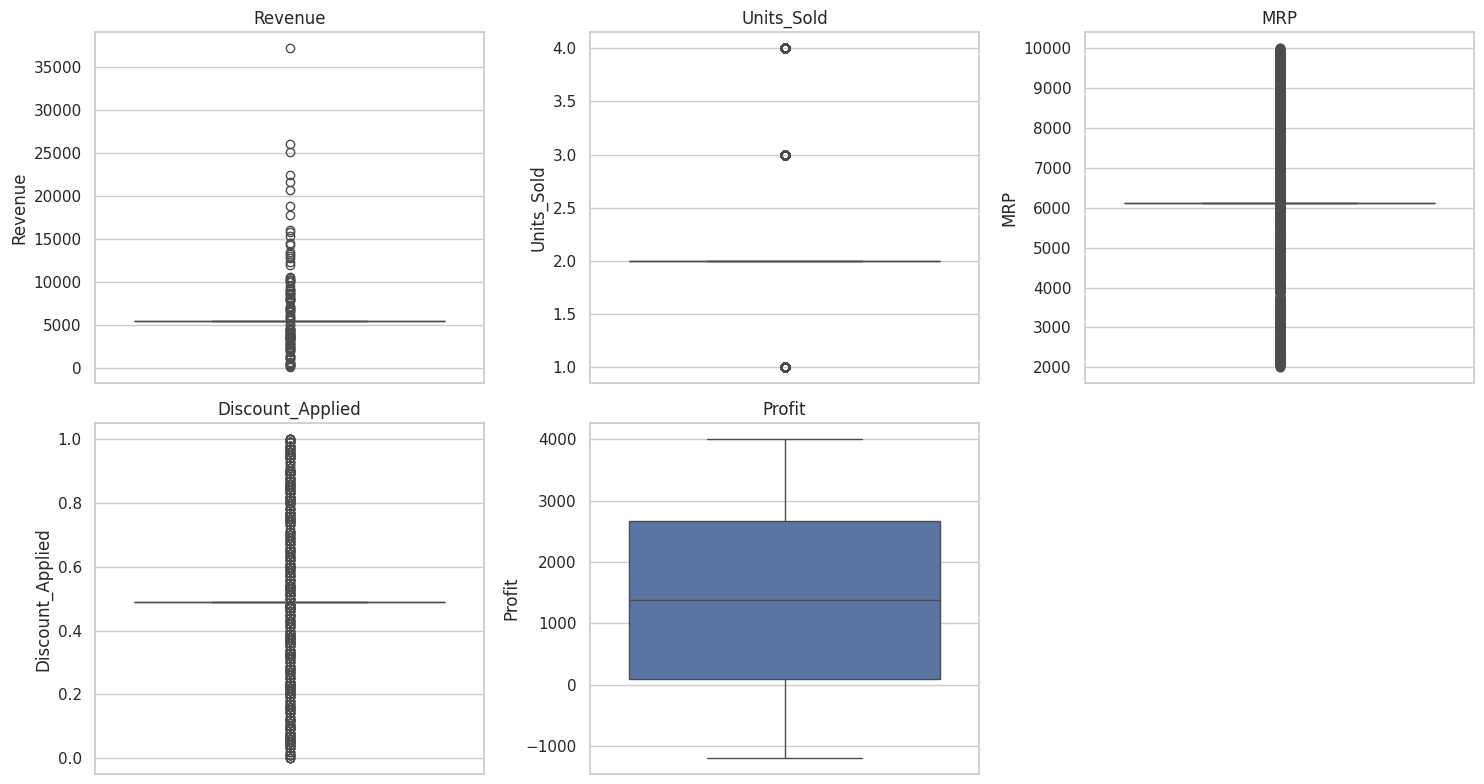

In [541]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_task2[col])
    plt.title(col)

plt.tight_layout()
plt.show()

- Revenue produced a more reasonable number of outliers (112 records) 
- Profit showed a natural distribution and no outliers were detected. 
- Units_Sold / MRP / Discount_Applied has equal quartiles and illogical number of outliers.
Therefore, Revenue was selected to demonstrate outlier handling because it provided the most meaningful balance between having detectable outliers and maintaining a reasonable data distribution.

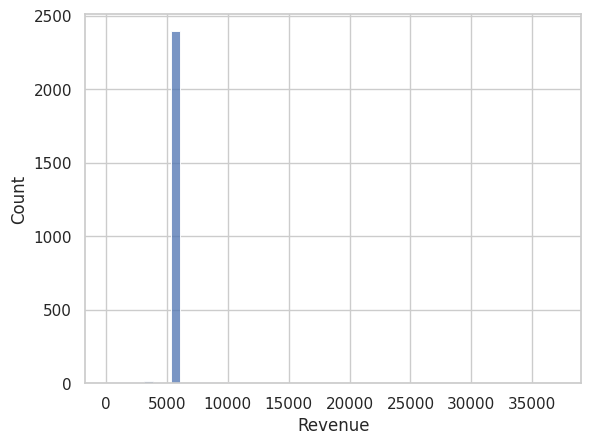

In [542]:
sns.histplot(df_task3['Revenue'], bins=50)
plt.show()

In [543]:
print("Minimum Revenue:", df_task3['Revenue'].min())
print("Maximum Revenue:", df_task3['Revenue'].max())

Minimum Revenue: 157.68
Maximum Revenue: 37169.35


The histogram shows that most Revenue values are concentrated around 5,500. This happend because a large number of missing and invalid Revenue values were replaced using median imputation during data preprocessing. As a result, many records share the same Revenue value, creating a large peak in the distribution. 
A small number of records have much higher/lower Revenue values, higher revenue values were identified as potential outliers using the IQR method.

In [544]:
Q1 = df_task3['Revenue'].quantile(0.25)
Q3 = df_task3['Revenue'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_task3[(df_task3['Revenue'] < lower) | (df_task3['Revenue'] > upper)]
outliers.head(15)

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
16,2016,Women,Basketball,Air Jordan,M,1,9871.75,0.30,6910.22,2024-12-21,Retail,Hyderabad,2452.69
31,2031,Men,Soccer,Premier III,L,4,3493.04,0.82,2514.99,2024-05-09,Online,Delhi,350.70
57,2048,Men,Lifestyle,Waffle One,M,3,6216.29,0.94,1118.93,2024-12-21,Online,Mumbai,-642.02
63,2063,Women,Basketball,Air Jordan,M,1,9751.00,0.16,8190.84,2024-12-21,Retail,Pune,1130.31
71,2071,Kids,Lifestyle,Blazer Mid,M,3,7849.81,0.49,12010.21,2024-12-21,Retail,Pune,-882.96
114,2114,Women,Training,Flex Trainer,XL,1,3167.33,0.53,1488.65,2024-12-21,Retail,Pune,1567.37
135,2135,Men,Basketball,Zoom Freak,L,2,9106.61,0.74,4735.44,2024-11-03,Retail,Hyderabad,2422.38
150,2150,Women,Basketball,LeBron 20,M,2,3313.21,0.48,3445.74,2024-12-21,Online,Bangalore,3221.62
169,2169,Kids,Training,Flex Trainer,L,4,4046.05,0.01,16022.36,2024-12-21,Retail,Delhi,1057.58
185,2185,Women,Training,ZoomX Invincible,XL,4,4207.44,0.59,6900.20,2024-12-21,Online,Kolkata,-615.48


In [545]:

df_task3['Revenue'] = df_task3['Revenue'].clip(lower, upper)

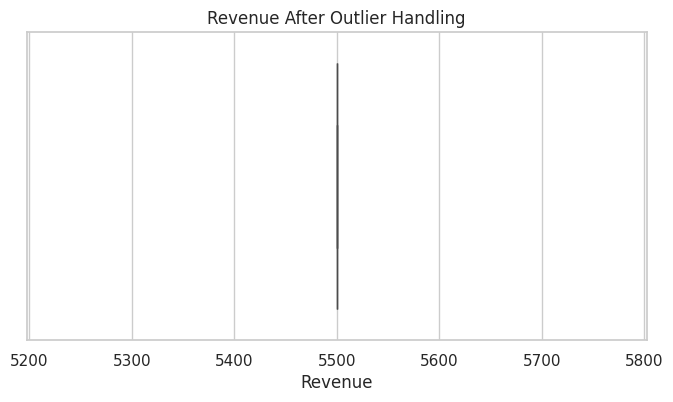

In [546]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_task3['Revenue'])
plt.title("Revenue After Outlier Handling")
plt.show()

In [547]:
outliers_after = df_task3[
    (df_task3['Revenue'] < lower) |
    (df_task3['Revenue'] > upper)
]

print("Remaining Outliers:", len(outliers_after))

Remaining Outliers: 0


After handling outliers, the Revenue column no longer contains any detected outliers. The boxplot shows that all values are now within the IQR limits. However, because many Revenue values were previously replaced with the median, most observations became concentrated around the same value, resulting in very low variability and a collapsed boxplot

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.



### 4.1 Min-Max Normalization 

In [548]:
df_task4 = df_task3.copy()

df_task4[numeric_cols].head()

,Revenue,Units_Sold,MRP,Discount_Applied,Profit
0,5499.82,2,6110.03,0.47,-770.45
1,5499.82,3,4957.93,0.49,-112.53
2,5499.82,4,6110.03,0.49,3337.34
3,5499.82,2,9673.57,0.49,3376.85
4,5499.82,2,6110.03,0.49,187.89


In [549]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df_task3[numeric_cols].copy()

df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_minmax)

df_minmax.head()

,Revenue,Units_Sold,MRP,Discount_Applied,Profit
0,0.0,0.333333,0.513593,0.47,0.082521
1,0.0,0.666667,0.369393,0.49,0.209077
2,0.0,1.000000,0.513593,0.49,0.872684
3,0.0,0.333333,0.959616,0.49,0.880285
4,0.0,0.333333,0.513593,0.49,0.266865


In [550]:
df_minmax.describe()

,Revenue,Units_Sold,MRP,Discount_Applied,Profit
count,2500.0,2500.000000,2500.000000,2500.000000,2500.000000
mean,0.0,0.387733,0.509216,0.491500,0.495409
std,0.0,0.228219,0.204629,0.148214,0.284433
min,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.333333,0.513593,0.490000,0.248715
50%,0.0,0.333333,0.513593,0.490000,0.494519
75%,0.0,0.333333,0.513593,0.490000,0.742517
max,0.0,1.000000,1.000000,1.000000,1.000000


In [551]:
df_task4['Revenue'].nunique()

1

In [552]:
df_task4['Revenue'].value_counts().head(10)

Revenue
5499.82    2500
Name: count, dtype: int64

After applying Min-Max normalization, Revenue was scaled to a constant value of 0 because the feature had almost no variability after the missing value imputation step.
Most missing and invalid revenue values were replaced using the median, causing the majority of records to share the same value (5499.82)

the Revenue feature lost its variability and became unsuitable for further analysis such as PCA.

### 4.2 Z-Score Standardization


In [553]:
from sklearn.preprocessing import StandardScaler

z_scaler = StandardScaler()

df_zscore = df_task3[numeric_cols].copy()

df_zscore[numeric_cols] = z_scaler.fit_transform(df_zscore)

df_zscore.head()

,Revenue,Units_Sold,MRP,Discount_Applied,Profit
0,0.0,-0.238416,0.021395,-0.145089,-1.451907
1,0.0,1.222465,-0.683435,-0.010122,-1.006878
2,0.0,2.683346,0.021395,-0.010122,1.326677
3,0.0,-0.238416,2.201492,-0.010122,1.353403
4,0.0,-0.238416,0.021395,-0.010122,-0.803668


In [554]:
df_zscore.describe()

,Revenue,Units_Sold,MRP,Discount_Applied,Profit
count,2500.0,2.500000e+03,2.500000e+03,2500.000000,2.500000e+03
mean,0.0,3.311129e-16,2.984279e-16,0.000000,-5.684342e-17
std,0.0,1.000200e+00,1.000200e+00,1.000200,1.000200e+00
min,0.0,-1.699296e+00,-2.488977e+00,-3.316803,-1.742090e+00
25%,0.0,-2.384157e-01,2.139453e-02,-0.010122,-8.674931e-01
50%,0.0,-2.384157e-01,2.139453e-02,-0.010122,-3.130361e-03
75%,0.0,-2.384157e-01,2.139453e-02,-0.010122,8.689486e-01
max,0.0,2.683346e+00,2.398882e+00,3.431525,1.774378e+00


Revenue remained constant after preprocessing because most invalid values were replaced using median imputation. As a result, Revenue had no variability (standard deviation = 0) and contributed little information during normalization.

- **Task 5**
Apply PCA and interpret explained variance.




###  5.1 Observe

In [555]:
pca_cols = [
    'Units_Sold',
    'MRP',
    'Discount_Applied',
    'Profit'
]

df_task5 = df_task4.copy()

In [556]:
df_task5[pca_cols].head()

,Units_Sold,MRP,Discount_Applied,Profit
0,2,6110.03,0.47,-770.45
1,3,4957.93,0.49,-112.53
2,4,6110.03,0.49,3337.34
3,2,9673.57,0.49,3376.85
4,2,6110.03,0.49,187.89


### 5.2 Correlation Matrix

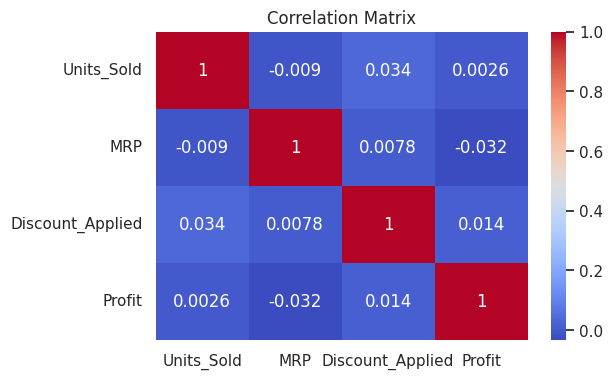

In [557]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    df_task5[pca_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix indicates very weak relationships between all numerical features, with correlation values close to zero. This means that the variables are independent and do not contain much shared information and lack linear pattern.

Overall, PCA is not very useful for this dataset because the numerical features show very weak correlations.

### 5.3 Explained Variance Ratio

In [558]:
from sklearn.decomposition import PCA

X = df_zscore[['Units_Sold', 'MRP', 'Discount_Applied', 'Profit']]

pca = PCA(n_components=4)

principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.26059825 0.25617014 0.24510965 0.23812195]


Four principal components were retained because the variance was distributed almost equally across all components

- PC1 = 26.06%
- PC2 = 25.62%
- PC3 = 24.51%
- PC4 = 23.81%

Therefore, PCA cannot reduce the dimensionality significantly without losing information.



### 5.4 PCA Projection

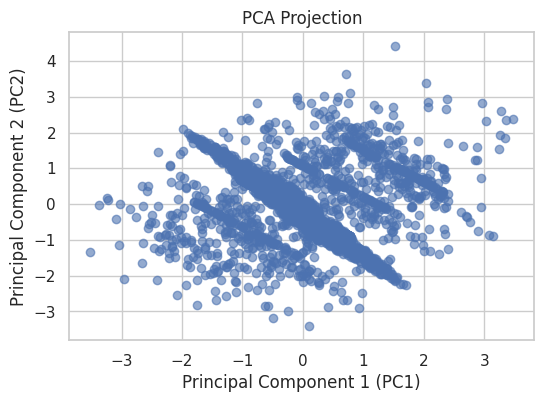

In [559]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    principal_components[:,0],
    principal_components[:,1],
    alpha=0.6
)

plt.title("PCA Projection")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

plt.show()

The PCA projection shows the data after reducing it into two principal components (PC1 and PC2). Each point represents one sales record. 
The points are spread across the graph and do not form a clear pattern or single direction. 

This matches the heatmap  results, which showed very weak relationships between the numerical features.

Therefore,  PCA cannot significantly reduce the dataset dimensions without losing important information.

End of Assignment 2